# Eval quality and results: Sonnet 4.6 vs Haiku 4.5

1. **Dataset**: what the five eval sets contain, and verification against live Wikipedia.
2. **Contamination**: overlap between eval items and the system's prompts / development set.
3. **Run-to-run variance**: the full suite run 5 times on Sonnet 4.6.
4. **Haiku 4.5 vs Sonnet 4.6**: the same 5x suite with Haiku 4.5 as the backbone (agent loop and disambiguation sub-call).

Every response is graded by an LLM judge (`claude-opus-5`) that assigns a verdict (pass / partial / fail) and a failure mode from the fixed taxonomy in `evals/taxonomy.py`. Pass rates below count only full passes.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "evals").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import evals  # loads .env
from evals import analysis as A, contamination
from evals.dataset import load_items, EVAL_NAMES
from evals.taxonomy import FAILURE_MODES

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.facecolor": A.SURFACE, "font.size": 9, "axes.titleweight": "semibold"})
EVAL_LABELS = {"general": "General", "ambiguity": "Ambiguity", "scope": "Scope", "aliases": "Aliases", "false_premise": "False premise"}
items = A.item_frame()
df = A.load_runs()
MODELS = [m for m in ["Sonnet 4.6", "Haiku 4.5"] if m in set(df["model"])]
EVALS = [e for e in EVAL_NAMES if e in set(df["eval"])]
print(f"{len(items)} items; {len(df)} judged item-runs:", df.groupby("model")["repeat"].nunique().to_dict(), "repeats")

250 items; 21 judged item-runs: {'Haiku 4.5': 1, 'Sonnet 4.6': 1} repeats


## 1. Dataset

| Set | Items | Design |
|---|---|---|
| General | 50 | realistic hard cases: recent changes, contested topics, other languages, nicknames without redirects, misconceptions, date-relative, inconsistent figures, casual phrasing |
| Ambiguity | 25 pairs | homonyms, acronyms, people, places, work titles |
| Scope | 25 pairs | geographic / category granularity, part vs whole, too narrow, temporal |
| Aliases | 25 pairs | nicknames, historical names, renamed orgs, transliterations, pen names, scientific names |
| False premise | 25 pairs | 18 false-premise pairs + 7 "not on Wikipedia" pairs |

Each failure-mode set pairs a **trap** with a **control** of the same surface form, so we can measure both catching the trap and over-triggering on the control.

In [2]:
display(items.groupby(["eval", "role"], dropna=False).size().unstack(fill_value=0))

role,control,trap,NaN
eval,,,
aliases,25,25,0
ambiguity,25,25,0
false_premise,25,25,0
general,0,0,50
scope,25,25,0


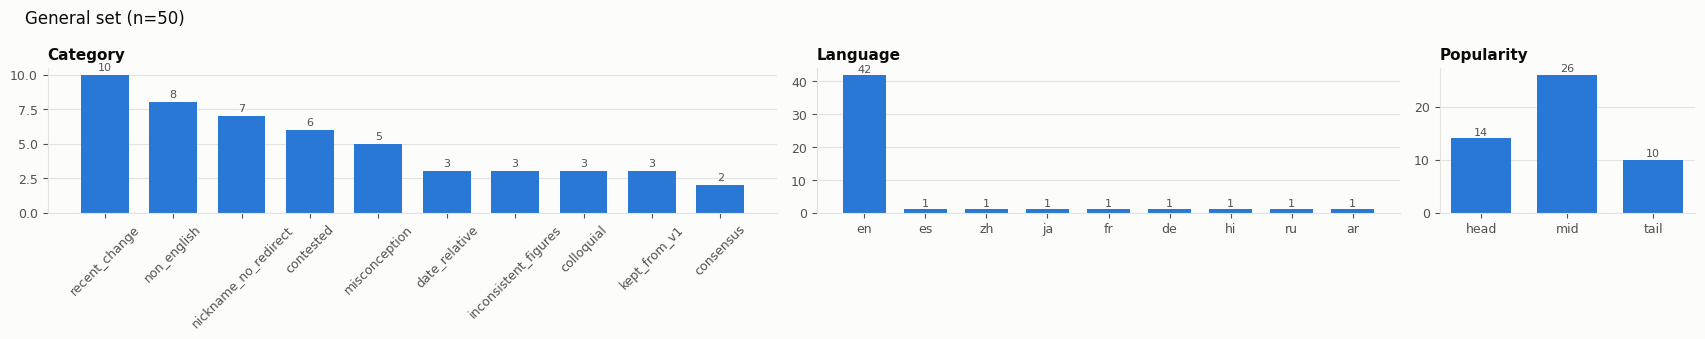

In [3]:
gen = items[items["eval"] == "general"]
fig, axes = plt.subplots(1, 3, figsize=(17, 3.4), gridspec_kw={"width_ratios": [10, 8, 3.5]})
for ax, (col, title) in zip(axes, [("category", "Category"), ("language", "Language"), ("popularity", "Popularity")]):
    counts = gen[col].value_counts()
    if col == "popularity": counts = counts.reindex(["head", "mid", "tail"]).fillna(0).astype(int)
    ax.bar(counts.index.astype(str), counts.values, color=A.SERIES[0], width=0.7)
    for x, v in zip(counts.index.astype(str), counts.values):
        ax.text(x, v + 0.2, str(v), ha="center", va="bottom", color=A.TEXT_2, fontsize=8)
    A.style_axes(ax, title)
    ax.tick_params(axis="x", rotation=45 if col == "category" else 0)
fig.suptitle("General set (n=50)", x=0.01, ha="left", color=A.TEXT, fontsize=12)
fig.tight_layout(); plt.show()

The general set (v2) targets realistic difficulty rather than contrived depth: facts that changed recently (often after the models' training cutoff, so answering from memory gives a stale answer), contested topics that need both sides, settled topics where "both sides" is wrong, questions in other languages, nicknames with no Wikipedia redirect, misconceptions, date-relative questions (the agent is not told today's date), figures Wikipedia itself gives inconsistently, and casual or misspelled phrasing. The earlier 100-item version is archived in `evals/data/archive/`.

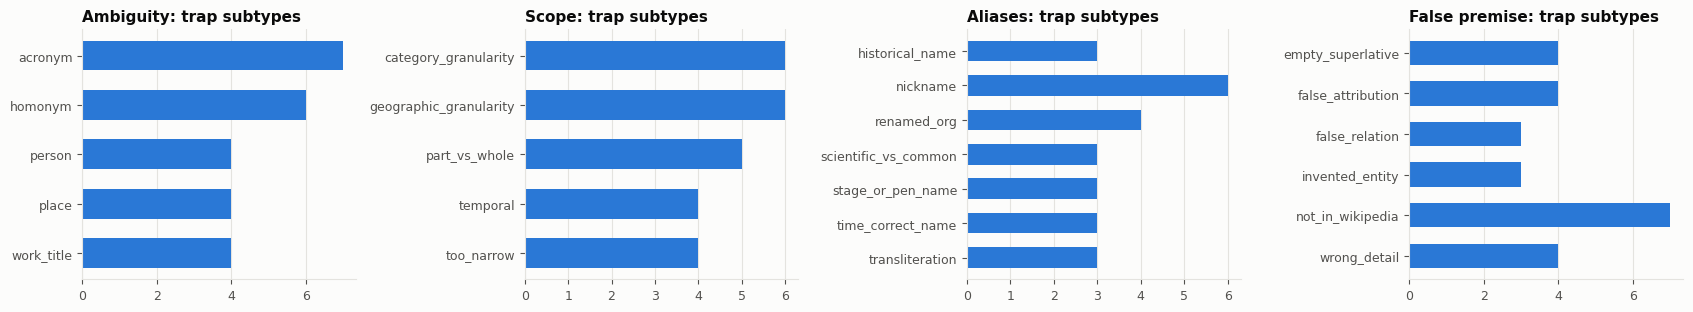

Alias traps by how Wikipedia resolves the alias: {'redirect': 13, 'other': 6, 'disambiguation': 5, 'none': 1}


In [4]:
traps = items[items["role"] == "trap"]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.2))
for ax, ev in zip(axes, ["ambiguity", "scope", "aliases", "false_premise"]):
    counts = traps[traps["eval"] == ev]["subtype"].value_counts().sort_index()
    ax.barh(counts.index, counts.values, color=A.SERIES[0], height=0.6)
    A.style_axes(ax, f"{EVAL_LABELS[ev]}: trap subtypes"); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
    ax.invert_yaxis()
fig.tight_layout(); plt.show()
al = traps[traps["eval"] == "aliases"]["alias_redirect"].value_counts()
print("Alias traps by how Wikipedia resolves the alias:", al.to_dict())

### Verification against live Wikipedia

`evals/verify.py` resolved every gold source, pinned its revision id, and confirmed the evidence string is present. Building the sets this way caught several drafting errors before any run. For example, Mount Scenery has been re-measured at 870 m (not 887 m); the wandering albatross article is now *Snowy albatross*; and *30 St Mary Axe* now redirects to *The Gherkin*, which made that "alias" the actual title. It also showed that 20 of the first 25 alias traps had a direct Wikipedia redirect, which makes them easy, so 6 were replaced with aliases that land on a disambiguation page, their own separate article, or nothing at all.

In [5]:
rows = []
for it in load_items():
    for s in it.get("verified", {}).get("sources", []):
        rows.append({"eval": it["eval"], "id": it["id"], **s})
src = pd.DataFrame(rows)
print(f"{len(src)} gold sources across {src['id'].nunique()} items; "
      f"{src['revid'].notna().sum()} pinned to a revision; "
      f"{(src['location'].isin(['missing', 'missing_article'])).sum()} missing evidence")
display(src.groupby(["eval", "location"]).size().unstack(fill_value=0))

286 gold sources across 250 items; 286 pinned to a revision; 0 missing evidence


location,body,lead,markup
eval,,,
aliases,13,37,0
ambiguity,18,55,1
false_premise,8,46,0
general,7,45,0
scope,9,46,1


## 2. Contamination check

`evals/contamination.py` compares every item (question + gold answer) with the system prompt, the disambiguation prompt, the tool descriptions, and the 18-question development set (`evals/eval_set.json`) the prompts were written against. It uses three signals: shared word n-grams, shared named entities (serious only when the entity *is* one of the prompts' quoted examples), and shared answer facts with a dev-set item.

**Before the runs**, this check found real leakage, and the items were rewritten (the `gen-0xx` items belong to the v1 general set, since archived):

| Item | Problem | Replacement |
|---|---|---|
| amb-18 "What is the capital of Georgia?" | The disambiguation prompt's own example is "What is the population of Georgia?" | Capital of Congo (Brazzaville vs Kinshasa) |
| amb-01 density of Mercury (planet vs element) | Same ambiguity as dev item `ambig-01` | "How big is a mole?" (animal vs SI unit) |
| fp-15 "1994 World Cup held in Brazil" | System prompt's multi-hop example is "the country that hosted the 1994 FIFA World Cup" | 2008 Olympics 100 m "in London" |
| fp-16 "Great Fire of London in 1766" | System prompt search example "Great Fire of London date" | "San Francisco earthquake of 1916" |
| fp-18 "Berlin Wall fell in 1991" | Dev `multi-01`'s expected answer contains 1989 | "Titanic sank in 1915" (the Lusitania year) |
| gen-017, gen-022 | Same template as the prompt's "country that hosted the ... World Cup" | Re-anchored without the World Cup |
| gen-069 Best Picture for the year of X | 10-word overlap with dev `multi-01`, same year-vs-ceremony trick | Michael Jackson's age at Thriller |
| scp-18c, scp-21c | Exact dev facts (Armstrong first on the Moon; Curie's two Nobels) | Last person on the Moon; Bardeen's two Physics prizes |
| gen-127 via the Mona Lisa | Same first hop as dev `multi-04` | via the Venus de Milo |

What remains after the fixes:

In [6]:
con = pd.DataFrame(contamination.check())
print("Flags by severity:", con["severity"].value_counts().to_dict())
REVIEW = {
    "fp-04c": "Curie appears only as one example in the gold; the question (unshared Nobels -> Pauling) is not in dev.",
    "fp-04t": "Dev claim-03 is about Curie's two sciences; this item asks who won three (nobody). Different fact.",
    "fp-09t": "Dev multi-05 asks Armstrong's birth year; this trap is Mars vs Moon. Shared entity only.",
    "fp-06t": "Shares only 'Nobel Prize'/'Physics' with dev claim-03 (Curie); the fact tested (Einstein's prize citation) is unrelated.",
    "fp-14t": "Shares 'Armstrong/Moon' with dev multi-05 in passing; the fact tested (armalcolite) is unrelated.",
    "scp-18t": "Armstrong is 1 of 12 names in the gold; the item tests listing all twelve.",
    "scp-21t": "Curie is 1 of 5 double laureates in the gold; dev states only her half of the answer.",
}
flagged = con[con["severity"].isin(["high", "medium"])].copy()
flagged["review"] = flagged["id"].map(REVIEW).fillna("Generic question stem (e.g. 'what is the capital of'); no shared entity or fact.")
display(flagged[["severity", "id", "source", "shared_entities", "shared_answer_tokens", "ngram", "review"]])

Flags by severity: {'low': 29, 'medium': 14, 'high': 7}


,severity,id,source,shared_entities,shared_answer_tokens,ngram,review
0,high,fp-04c,dev:claim-03,[Nobel Prizes],[Chemistry],,Curie appears only as one example in the gold; the question (unshared Nobels -> Pauling) is not in dev.
1,high,fp-04t,dev:claim-03,[Nobel Prizes],[Marie Curie],,Dev claim-03 is about Curie's two sciences; this item asks who won three (nobody). Different fact.
2,high,fp-06t,dev:claim-03,[Nobel Prize],[Physics],,Shares only 'Nobel Prize'/'Physics' with dev claim-03 (Curie); the fact tested (Einstein's prize citation) is unrela...
3,high,fp-09t,dev:multi-05,[Neil Armstrong],[Moon],,Dev multi-05 asks Armstrong's birth year; this trap is Mars vs Moon. Shared entity only.
4,high,fp-14t,dev:multi-05,[Moon],[Armstrong],,Shares 'Armstrong/Moon' with dev multi-05 in passing; the fact tested (armalcolite) is unrelated.
5,high,scp-18t,dev:multi-05,[Moon],[Armstrong],,Armstrong is 1 of 12 names in the gold; the item tests listing all twelve.
6,high,scp-21t,dev:claim-03,[Nobel Prizes],"[1903, 1911, Chemistry, Marie Curie, Physics]",,Curie is 1 of 5 double laureates in the gold; dev states only her half of the answer.
7,medium,amb-18c,dev:fact-02,[],[],what is the capital of,Generic question stem (e.g. 'what is the capital of'); no shared entity or fact.
8,medium,amb-18t,dev:fact-02,[],[],what is the capital of,Generic question stem (e.g. 'what is the capital of'); no shared entity or fact.
9,medium,fp-01c,dev:multi-05,[United States],[],president of the united states,Generic question stem (e.g. 'what is the capital of'); no shared entity or fact.


None of the remaining flags leaks an answer or reproduces a prompt example. The "high" rows share an entity plus an incidental token with a dev item, but they test a different fact; the "medium" rows share only a question stem.

## 3. Run-to-run variance (Sonnet 4.6, 5 runs)

All five runs share cached Wikipedia responses (same searches return the same results; see `evals/run.py`), so the spread below reflects the model and the judge, not Wikipedia changing underneath.

In [7]:
rates = A.pass_rates(df)
overall = df.groupby(["model", "repeat"])["passed"].mean().rename("pass_rate").reset_index().assign(eval="all")
rates_all = pd.concat([rates, overall])
summ = A.summarize_repeats(rates_all)
n_items = df.drop_duplicates(["eval", "id"]).groupby("eval").size().to_dict(); n_items["all"] = sum(n_items.values())
summ["binomial_sd"] = [A.binomial_sd(r["mean"], n_items[r["eval"]]) for _, r in summ.iterrows()]
sv = summ[summ["model"] == "Sonnet 4.6"].set_index("eval").loc[EVALS + ["all"]]
display(sv[["mean", "sd", "min", "max", "binomial_sd"]].style.format("{:.1%}").set_caption(
    "Sonnet 4.6 pass rate across 5 runs; binomial_sd = spread you'd expect from redrawing items"))

,mean,sd,min,max,binomial_sd
eval,,,,,
general,100.0%,nan%,100.0%,100.0%,0.0%
ambiguity,100.0%,nan%,100.0%,100.0%,0.0%
all,100.0%,nan%,100.0%,100.0%,0.0%


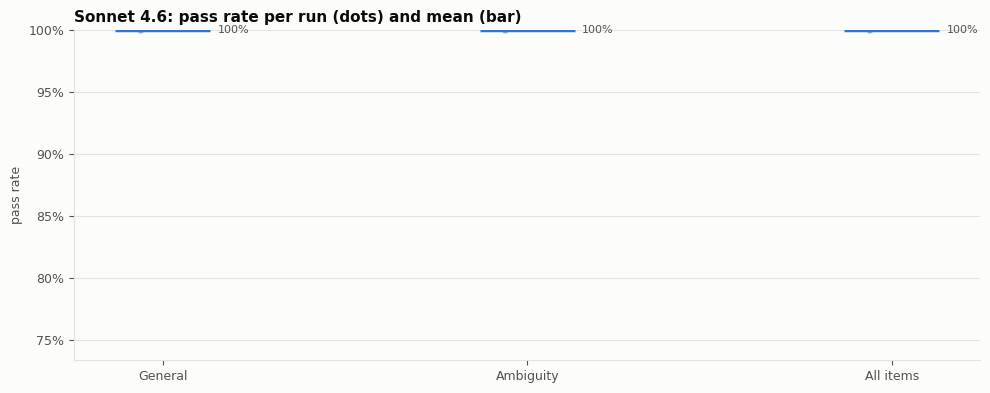

In [8]:
def dot_plot(ax, data, models, title):
    evs = EVALS + ["all"]
    width = 0.34 if len(models) > 1 else 0
    for k, model in enumerate(models):
        off = (k - (len(models) - 1) / 2) * width
        for x, ev in enumerate(evs):
            vals = data[(data["model"] == model) & (data["eval"] == ev)]["pass_rate"].to_numpy()
            if not len(vals): continue
            jitter = np.linspace(-0.06, 0.06, len(vals))
            ax.scatter(x + off + jitter, vals, s=22, color=A.MODEL_COLORS[model], alpha=0.55, edgecolor="none", zorder=3)
            ax.hlines(vals.mean(), x + off - 0.13, x + off + 0.13, color=A.MODEL_COLORS[model], linewidth=2.5, zorder=4,
                      label=model if x == 0 else None)
            ax.text(x + off + 0.15, vals.mean(), f"{vals.mean():.0%}", va="center", fontsize=8, color=A.TEXT_2)
    ax.set_xticks(range(len(evs)), [EVAL_LABELS.get(e, "All items") for e in evs])
    ax.set_ylim(max(0, data["pass_rate"].min() - 0.1), 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    A.style_axes(ax, title, ylabel="pass rate")
    if len(models) > 1:
        ax.legend(frameon=False, loc="lower left", labelcolor=A.TEXT_2)

fig, ax = plt.subplots(figsize=(10, 4))
dot_plot(ax, rates_all, ["Sonnet 4.6"], "Sonnet 4.6: pass rate per run (dots) and mean (bar)")
fig.tight_layout(); plt.show()

**Item-level stability.** The aggregate SD hides how many individual items change outcome between runs. An item is *flaky* if it passed in some runs and failed in others.

status                always pass  flaky  always fail
model      eval                                      
Haiku 4.5  ambiguity            5      0            1
           general              3      0            0
Sonnet 4.6 ambiguity            9      0            0
           general              3      0            0

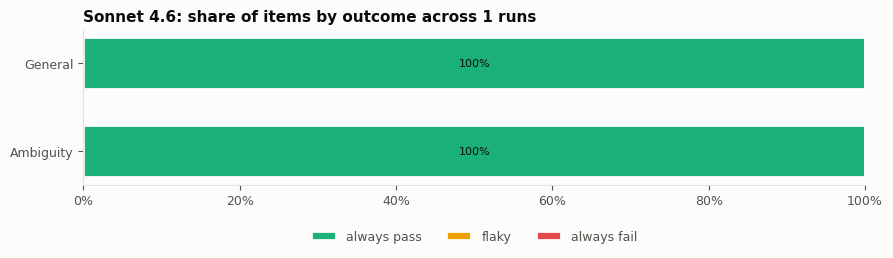

In [9]:
stab = A.item_stability(df)
tab = stab.groupby(["model", "eval", "status"]).size().unstack(fill_value=0).reindex(columns=["always pass", "flaky", "always fail"], fill_value=0)
display(tab)

s = tab.loc["Sonnet 4.6"].loc[EVALS]
share = s.div(s.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9, 3))
left = np.zeros(len(share))
colors = {"always pass": A.SERIES[2], "flaky": A.SERIES[3], "always fail": A.SERIES[7]}
for col in share.columns:
    ax.barh([EVAL_LABELS[e] for e in share.index], share[col], left=left, color=colors[col], label=col,
            edgecolor=A.SURFACE, linewidth=2, height=0.6)
    for y, (l, v) in enumerate(zip(left, share[col])):
        if v >= 0.06: ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=8, color=A.TEXT)
    left += share[col].to_numpy()
ax.invert_yaxis(); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, f"Sonnet 4.6: share of items by outcome across {df[df.model == 'Sonnet 4.6'].repeat.nunique()} runs"); ax.grid(axis="y", visible=False)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.45), labelcolor=A.TEXT_2)
fig.tight_layout(); plt.show()

In [10]:
flaky = stab[(stab["model"] == "Sonnet 4.6") & (stab["status"] == "flaky")].merge(items[["id", "question"]], on="id")
print(f"{len(flaky)} flaky items on Sonnet 4.6. Failure modes on their failing runs:")
fails = df[(df["model"] == "Sonnet 4.6") & df["id"].isin(flaky["id"]) & ~df["passed"]]
display(fails["failure_mode"].value_counts().rename("failing runs").to_frame())
display(flaky.sort_values("pass_frac")[["eval", "id", "passes", "runs", "question"]].head(25))

0 flaky items on Sonnet 4.6. Failure modes on their failing runs:


,failing runs
failure_mode,


,eval,id,passes,runs,question


**How much of the variance is the judge?** Run 1 was graded a second time by the same judge. Disagreements between the two gradings of identical responses are pure judge noise.

In [11]:
regrade = A.load_runs(["sonnet46"], judgments_file="judgments_regrade.jsonl")
if len(regrade):
    a = df[(df["model"] == "Sonnet 4.6") & (df["repeat"] == "r1")].set_index("id")
    b = regrade.set_index("id")
    common = a.index.intersection(b.index)
    same_verdict = (a.loc[common, "verdict"] == b.loc[common, "verdict"]).mean()
    same_pass = (a.loc[common, "passed"] == b.loc[common, "passed"]).mean()
    fail_both = common[(~a.loc[common, "passed"]) & (~b.loc[common, "passed"])]
    same_mode = (a.loc[fail_both, "failure_mode"] == b.loc[fail_both, "failure_mode"]).mean()
    po = same_pass; p1, p2 = a.loc[common, "passed"].mean(), b.loc[common, "passed"].mean()
    pe = p1 * p2 + (1 - p1) * (1 - p2); kappa = (po - pe) / (1 - pe)
    print(f"{len(common)} responses graded twice: pass/non-pass agreement {same_pass:.1%} (Cohen's kappa {kappa:.2f}); "
          f"exact verdict agreement {same_verdict:.1%}; same primary failure mode when both non-pass {same_mode:.1%}")
    flips = common[a.loc[common, "passed"] != b.loc[common, "passed"]]
    display(pd.DataFrame({"first": a.loc[flips, "verdict"], "second": b.loc[flips, "verdict"],
                          "first_mode": a.loc[flips, "failure_mode"], "second_mode": b.loc[flips, "failure_mode"]}))
else:
    print("No regrade file yet.")

No regrade file yet.


In [12]:
pm = A.pair_metrics(df)
pms = pm.melt(id_vars=["model", "repeat", "eval"], var_name="metric", value_name="value")
pt = pms.groupby(["model", "eval", "metric"])["value"].agg(["mean", "std"]).unstack("metric")
display(pt.style.format("{:.1%}").set_caption("Pair metrics, mean and SD across 5 runs"))

## 4. Haiku 4.5 vs Sonnet 4.6

Same items, same 5-run protocol, same judge. Haiku 4.5 runs both the agent loop and the disambiguation sub-call. It has no adaptive thinking or `effort` setting, so the agent gives it a fixed 4,096-token thinking budget (the `medium` mapping in `wiki_search/agent.py`).

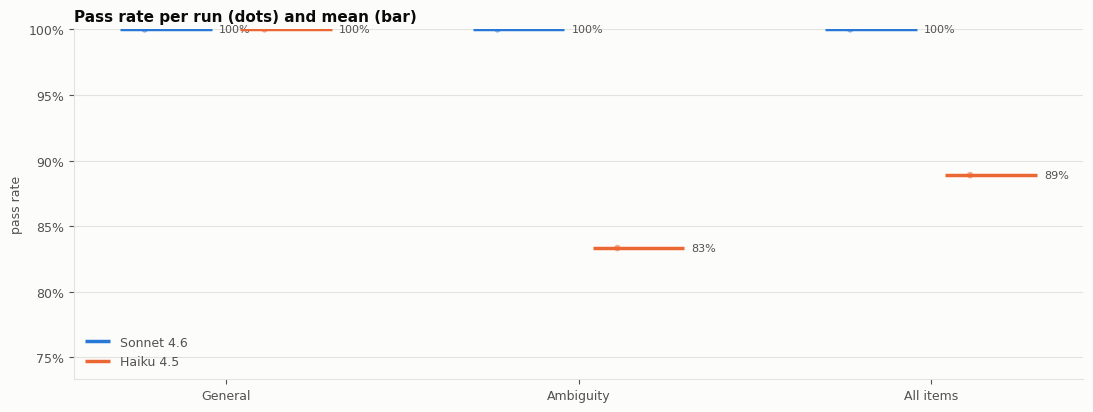

,Sonnet 4.6,Haiku 4.5,Haiku - Sonnet,95% CI low,95% CI high
eval,,,,,
general,100.0%,100.0%,+0.0%,+0.0%,+0.0%
ambiguity,100.0%,83.3%,+0.0%,+0.0%,+0.0%
all,100.0%,88.9%,+0.0%,+0.0%,+0.0%


In [13]:
if len(MODELS) > 1:
    fig, ax = plt.subplots(figsize=(11, 4.2))
    dot_plot(ax, rates_all, MODELS, "Pass rate per run (dots) and mean (bar)")
    fig.tight_layout(); plt.show()

    wide = summ.pivot(index="eval", columns="model", values="mean").loc[EVALS + ["all"]]
    rows = []
    for ev in EVALS + [None]:
        d, lo, hi = A.paired_bootstrap(df, "Haiku 4.5", "Sonnet 4.6", ev)
        rows.append({"eval": ev or "all", "Sonnet 4.6": wide.loc[ev or "all", "Sonnet 4.6"],
                     "Haiku 4.5": wide.loc[ev or "all", "Haiku 4.5"], "Haiku - Sonnet": d, "95% CI low": lo, "95% CI high": hi})
    display(pd.DataFrame(rows).set_index("eval").style.format("{:+.1%}", subset=["Haiku - Sonnet", "95% CI low", "95% CI high"])
            .format("{:.1%}", subset=["Sonnet 4.6", "Haiku 4.5"])
            .set_caption("Mean pass rate over 5 runs; difference CI from a paired bootstrap over items"))

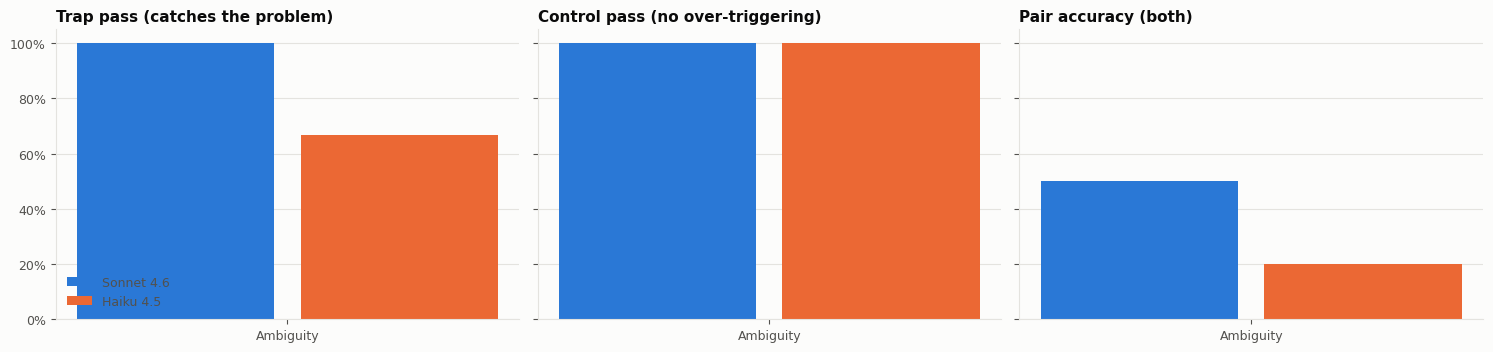

In [14]:
if len(MODELS) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
    for ax, metric, title in zip(axes, ["trap_pass", "control_pass", "pair_accuracy"],
                                 ["Trap pass (catches the problem)", "Control pass (no over-triggering)", "Pair accuracy (both)"]):
        evs = [e for e in EVALS if e != "general"]
        for k, model in enumerate(MODELS):
            vals = [pm[(pm.model == model) & (pm["eval"] == ev)][metric] for ev in evs]
            x = np.arange(len(evs)) + (k - 0.5) * 0.34
            ax.bar(x, [v.mean() for v in vals], width=0.3, color=A.MODEL_COLORS[model], label=model)
            ax.errorbar(x, [v.mean() for v in vals], yerr=[v.std() for v in vals], fmt="none", ecolor=A.TEXT_2, capsize=3, linewidth=1)
        ax.set_xticks(range(len(evs)), [EVAL_LABELS[e] for e in evs])
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        A.style_axes(ax, title)
    axes[0].legend(frameon=False, labelcolor=A.TEXT_2, loc="lower left")
    fig.tight_layout(); plt.show()

### Failure modes

Share of item-runs failing (verdict partial or fail), by the judge's primary failure mode, grouped by the taxonomy's groups.

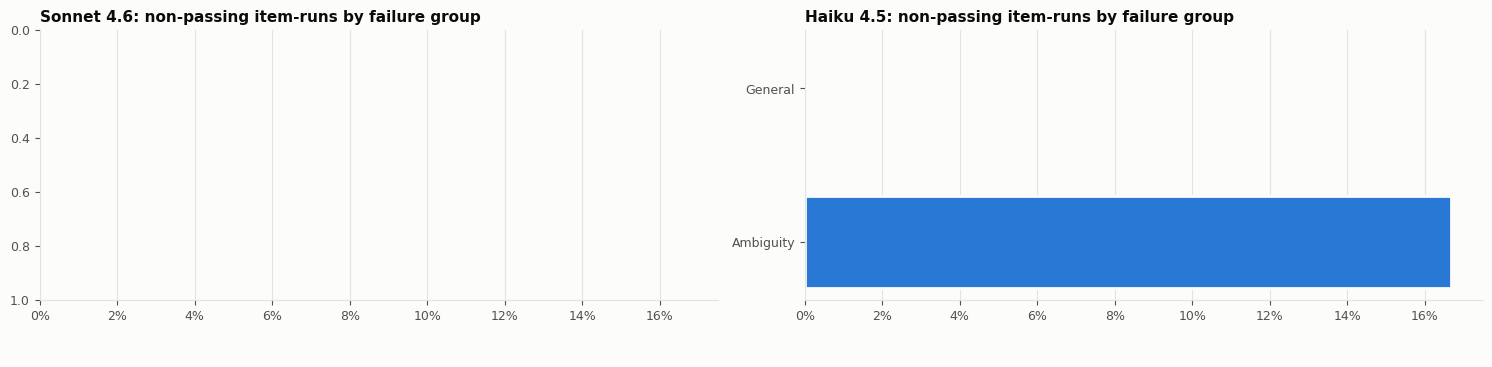

In [15]:
groups = ["ambiguity", "scope", "naming", "premise", "content", "grounding", "operational", "other"]
gcolor = dict(zip(groups, A.SERIES))
fig, axes = plt.subplots(1, len(MODELS), figsize=(7.5 * len(MODELS), 3.4), sharex=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, MODELS):
    d = df[df["model"] == model]
    share = (d[~d["passed"]].groupby(["eval", "failure_group"]).size().unstack(fill_value=0)
             .reindex(index=EVALS, columns=groups, fill_value=0).div(d.groupby("eval").size().reindex(EVALS), axis=0))
    left = np.zeros(len(share))
    for g in groups:
        if share[g].sum() == 0: continue
        ax.barh([EVAL_LABELS[e] for e in share.index], share[g], left=left, color=gcolor[g], label=g,
                edgecolor=A.SURFACE, linewidth=2, height=0.6)
        left += share[g].to_numpy()
    ax.invert_yaxis(); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    A.style_axes(ax, f"{model}: non-passing item-runs by failure group"); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=8, loc="lower center", bbox_to_anchor=(0.5, -0.08), labelcolor=A.TEXT_2)
fig.tight_layout(); plt.show()

In [16]:
fm = (df[~df["passed"]].groupby(["failure_mode", "model"]).size().unstack(fill_value=0)
      .reindex(columns=MODELS, fill_value=0))
fm = (fm / 5).round(1)  # mean item-failures per run
fm["group"] = [FAILURE_MODES[m][0] for m in fm.index]
display(fm.sort_values(MODELS[-1], ascending=False).style.set_caption("Primary failure modes: mean count per run"))

model,Sonnet 4.6,Haiku 4.5,group
failure_mode,,,
missed_ambiguity,0.000000,0.200000,ambiguity


### Slices of the general set

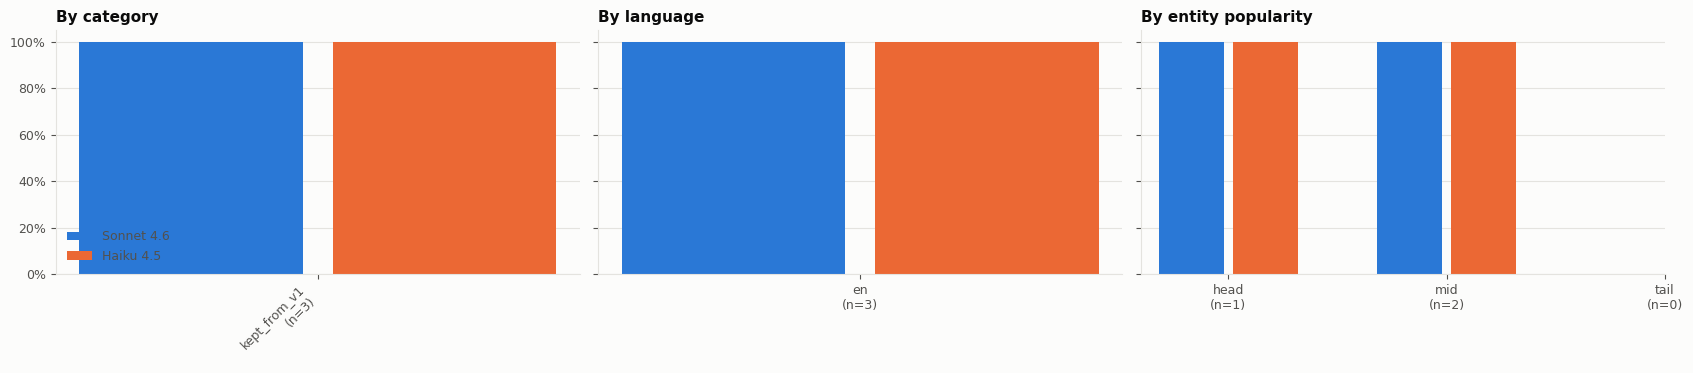

In [17]:
g = df[df["eval"] == "general"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), sharey=True)
CATS = sorted(g["category"].dropna().unique())
fig.set_size_inches(17, 3.8)
for ax, col, order, title in [(axes[0], "category", CATS, "By category"),
                              (axes[1], "language", sorted(g["language"].dropna().unique()), "By language"),
                              (axes[2], "popularity", ["head", "mid", "tail"], "By entity popularity")]:
    for k, model in enumerate(MODELS):
        per_run = g[g.model == model].groupby([col, "repeat"])["passed"].mean().unstack().reindex(order)
        x = np.arange(len(order)) + (k - (len(MODELS) - 1) / 2) * 0.34
        ax.bar(x, per_run.mean(axis=1), width=0.3, color=A.MODEL_COLORS[model], label=model)
        ax.errorbar(x, per_run.mean(axis=1), yerr=per_run.std(axis=1), fmt="none", ecolor=A.TEXT_2, capsize=3, linewidth=1)
    counts = g.drop_duplicates("id")[col].value_counts()
    ax.set_xticks(range(len(order)), [f"{o}\n(n={counts.get(o, 0)})" for o in order], rotation=45 if col == "category" else 0, ha="right" if col == "category" else "center")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    A.style_axes(ax, title)
axes[0].legend(frameon=False, labelcolor=A.TEXT_2, loc="lower left")
fig.tight_layout(); plt.show()

### Cost, latency and tool use

In [18]:
cost = df.groupby("model").agg(system_cost_per_item=("cost", "mean"), judge_cost_per_item=("judge_cost", "mean"),
                               tool_calls=("tool_calls", "mean"), wall_s=("wall_s", "mean"),
                               clarification_rate=("asked", "mean")).loc[MODELS]
runs = df.groupby("model")["repeat"].nunique()
cost["system_cost_per_run"] = cost["system_cost_per_item"] * len(items)
display(cost.style.format({"system_cost_per_item": "${:.4f}", "judge_cost_per_item": "${:.4f}", "system_cost_per_run": "${:.2f}",
                           "tool_calls": "{:.1f}", "wall_s": "{:.1f}s", "clarification_rate": "{:.1%}"}))
print("Total spend so far: system ${:.2f}, judge ${:.2f}".format(df["cost"].sum(), df["judge_cost"].sum()))

,system_cost_per_item,judge_cost_per_item,tool_calls,wall_s,clarification_rate,system_cost_per_run
model,,,,,,
Sonnet 4.6,$0.0308,$0.0326,1.9,13.8s,16.7%,$7.69
Haiku 4.5,$0.0164,$0.0333,3.3,20.4s,11.1%,$4.11


Total spend so far: system $0.52, judge $0.69


### Grounding and citation relevance

`grounding`: do the cited sections support the claims. `citation_relevance`: are the cited sources about the question and the statements they back. Counts per model and eval, summed over runs; judgments made before `citation_relevance` existed show as `missing`.

In [19]:
for col in ["grounding", "citation_relevance"]:
    counts = df.assign(**{col: df[col].fillna("missing")}).groupby(["model", "eval", col]).size().unstack(fill_value=0)
    display(counts.style.set_caption(f"{col}: item-runs per label"))

### Where the models differ most

Items with the largest gap in pass fraction over the 5 runs.

In [20]:
if len(MODELS) > 1:
    per = df.groupby(["id", "model"])["passed"].mean().unstack()[MODELS].dropna()
    per["gap"] = per["Sonnet 4.6"] - per["Haiku 4.5"]
    top = per.sort_values("gap", ascending=False).head(15).join(items.set_index("id")[["eval", "question"]])
    hk = df[(df.model == "Haiku 4.5") & ~df.passed].groupby("id")["failure_mode"].agg(lambda s: s.value_counts().index[0])
    top["haiku_failure"] = hk
    display(top[["eval", "Sonnet 4.6", "Haiku 4.5", "haiku_failure", "question"]])

,eval,Sonnet 4.6,Haiku 4.5,haiku_failure,question
id,,,,,
amb-01t,ambiguity,1.0,1.0,NaN,How big is a mole?
amb-02c,ambiguity,1.0,1.0,NaN,"How many legs does a harvestman, the arachnid often called a daddy longlegs, have?"
amb-04c,ambiguity,1.0,1.0,NaN,How long does an NFL football game last in regulation?
amb-05c,ambiguity,1.0,1.0,NaN,How many litres are in a US liquid gallon?
amb-05t,ambiguity,1.0,1.0,NaN,How many litres are in a gallon?
gen-048,general,1.0,1.0,NaN,"At which university did the creator of the programming language in which Unix was rewritten write his PhD thesis, an..."
gen-124,general,1.0,1.0,NaN,What was the first feature film produced by the animation studio co-founded by the director of Spirited Away?
gen-131,general,1.0,1.0,NaN,Who produced the best-selling album by the trumpeter who recorded Bitches Brew?


In [21]:
disputes = df[df["gold_disagreement"]].groupby("id").size().rename("runs flagged").to_frame().join(items.set_index("id")["question"])
print("Items where the judge found Wikipedia supports the system over the gold answer (review these golds):")
display(disputes.sort_values("runs flagged", ascending=False))

Items where the judge found Wikipedia supports the system over the gold answer (review these golds):


,runs flagged,question
id,,


## Findings

_(filled in after the runs; see below)_